# Customer Churn Prediction
### A machine learning project using pandas, numpy, matplotlib, and scikit-learn

**Goal:** Predict which customers are likely to cancel (churn) their telecom
service, based on their account details and services subscribed.

**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
~7,000 customer records with a `Churn` column (Yes/No) as the prediction target.

**Workflow:**
1. Load & explore the data
2. Clean the data
3. Exploratory Data Analysis (EDA) with visualizations
4. Preprocess data for machine learning
5. Train models (Logistic Regression + Random Forest)
6. Evaluate model performance
7. Interpret feature importance


## 1. Import Libraries

In [24]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Make plots look cleaner
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [25]:
# Basic shape and structure
print("Shape (rows, columns):", df.shape)
print()
df.info()


Shape (rows, columns): (7043, 20)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     

## 2. Load the Data

Update the file path below if your CSV isn't in the same folder as this notebook.

In [27]:
# Load the dataset
df = pd.read_csv(r"C:\Users\Kunal\Videos\customer_churn_data.csv")

# Preview the first few rows
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Cleaning

Real datasets are never perfectly clean. This section documents and fixes
issues found during exploration -- the same "explore before you trust it"
habit used in the SQL portion of this project.

In [6]:
# Check for missing values in each column
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Known issue with this dataset:** `TotalCharges` is loaded as a text
column (object dtype) instead of a number. This happens because a small
number of brand-new customers (tenure = 0) have a blank string instead of
a numeric value in that field. Converting it directly will fail silently
or throw an error unless we handle those blanks first.

In [7]:
# Attempt to convert TotalCharges to numeric, turning bad values into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# See how many rows became NaN as a result (these are the blank-string rows)
print("Rows with missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# These are new customers with 0 tenure -- it's reasonable to fill their
# TotalCharges with 0 rather than drop them, since they simply haven't
# been charged yet.
df['TotalCharges'] = df['TotalCharges'].fillna(0)


Rows with missing TotalCharges after conversion: 11


In [8]:
# Drop customerID -- it's a unique identifier with no predictive value,
# and including it would let the model 'memorize' individual customers
# instead of learning general patterns.
df = df.drop(columns=['customerID'])

# Confirm no missing values remain
print("Remaining missing values:\n", df.isnull().sum().sum())


Remaining missing values:
 0


## 4. Exploratory Data Analysis (EDA)

Before modeling anything, let's understand what drives churn visually.
Each chart here answers a specific business question.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


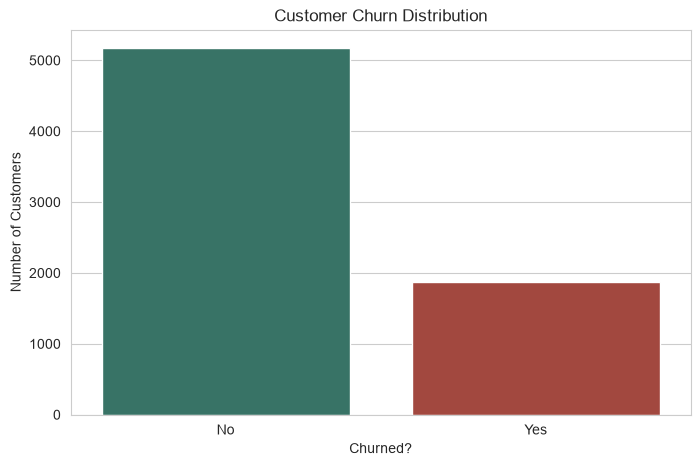

In [9]:
# How many customers churned overall? (class balance check --
# important for knowing if we need to handle imbalanced classes later)
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(churn_pct.round(1))

plt.figure()
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2E7D6B', '#B23A2E'], legend=False)
plt.title('Customer Churn Distribution')
plt.xlabel('Churned?')
plt.ylabel('Number of Customers')
plt.show()


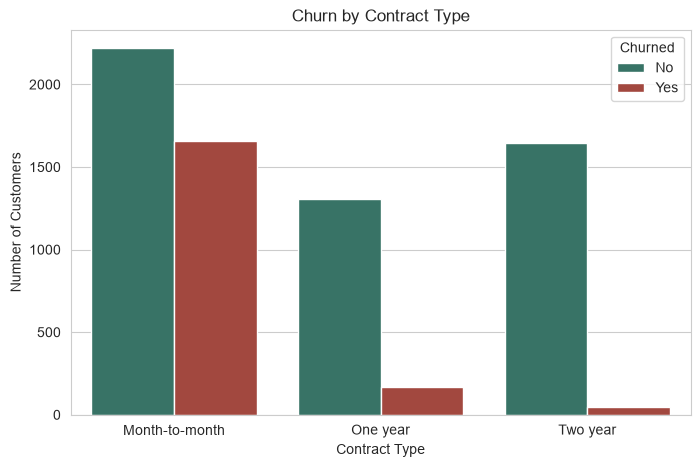

In [10]:
# Does contract type affect churn? (hypothesis: month-to-month
# customers churn more since they have no commitment)
plt.figure()
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2E7D6B', '#B23A2E'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churned')
plt.show()


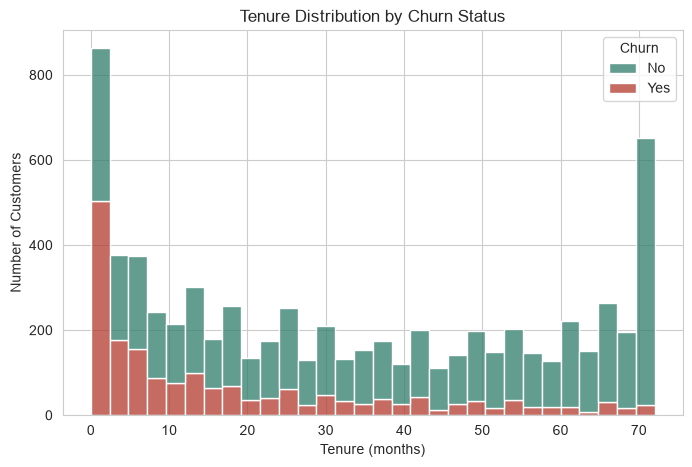

In [11]:
# Does tenure (how long they've been a customer) affect churn?
plt.figure()
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack',
             palette=['#2E7D6B', '#B23A2E'], bins=30)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()


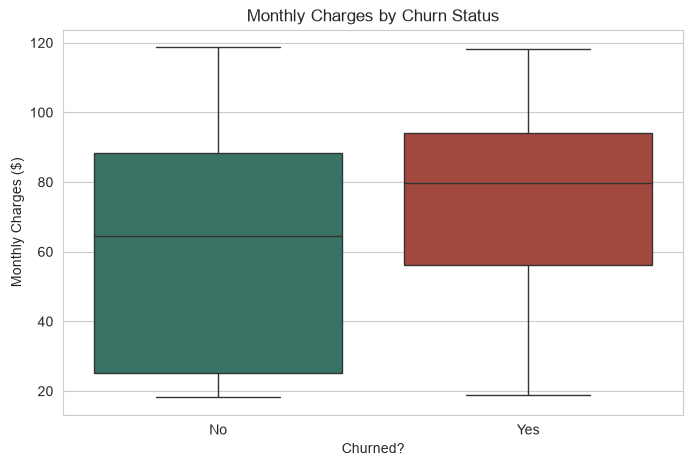

In [12]:
# Does monthly charge amount affect churn?
plt.figure()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn',
            palette=['#2E7D6B', '#B23A2E'], legend=False)
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churned?')
plt.ylabel('Monthly Charges ($)')
plt.show()


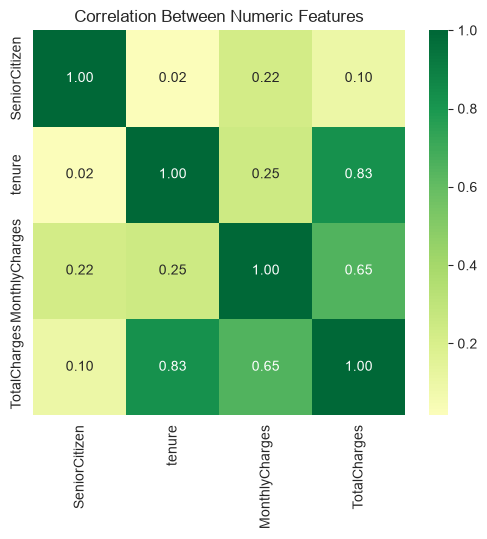

In [13]:
# Correlation heatmap of numeric features
# (helps spot which numeric variables move together)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.show()


## 5. Preprocessing for Machine Learning

Machine learning models need numbers, not text. This section converts
categorical columns (like 'Yes'/'No' or 'Month-to-month') into numeric
form, and separates our features (X) from our target (y).

In [14]:
# Encode the target column: Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Identify categorical columns (everything that isn't already numeric)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)


Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\Kunal\AppData\Local\Temp\ipykernel_6228\340728601.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [15]:
# One-hot encode categorical columns
# (turns e.g. 'Contract' into separate 0/1 columns per contract type,
# rather than assigning misleading numeric order to categories)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape before encoding: (7043, 20)
Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [16]:
# Separate features (X) from target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (7043, 30)
Target shape: (7043,)


In [17]:
# Split into training and test sets (80% train, 20% test)
# random_state ensures the split is reproducible every time you run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 5634
Test set size: 1409


In [18]:
# Scale numeric features so they're on a comparable range.
# This matters for Logistic Regression (distance-based math),
# less so for Random Forest, but doesn't hurt either model.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6. Model 1: Logistic Regression

A simple, interpretable baseline model -- good starting point for any
classification problem, and easy to explain in an interview.

In [19]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, log_preds), 3))
print()
print(classification_report(y_test, log_preds))


Logistic Regression Accuracy: 0.807

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 7. Model 2: Random Forest

An ensemble model that usually performs better than a single logistic
regression, and lets us extract feature importance afterward.

In [20]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)  # Random Forest doesn't need scaled features

rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_preds), 3))
print()
print(classification_report(y_test, rf_preds))


Random Forest Accuracy: 0.806

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



## 8. Compare Both Models

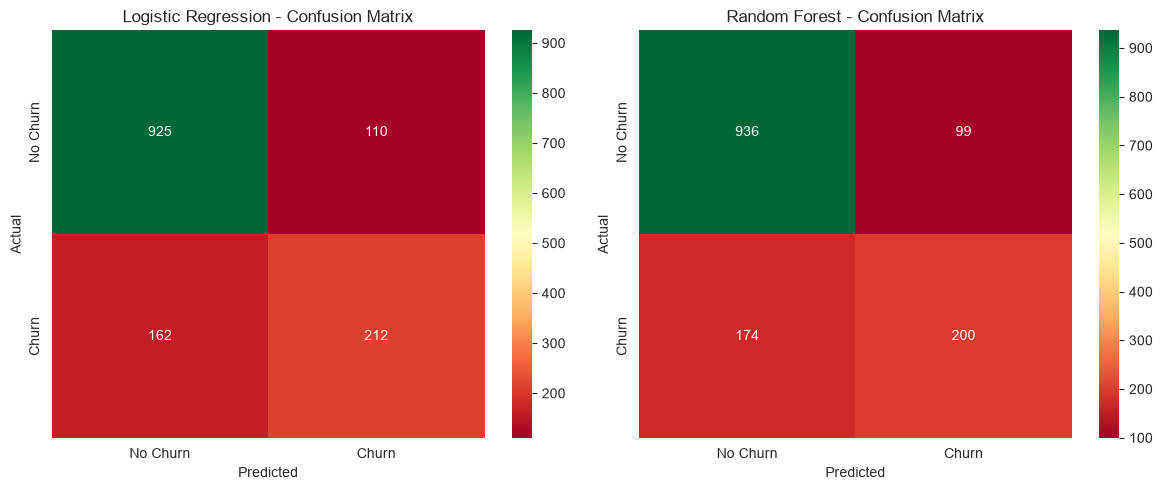

In [21]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes, [log_preds, rf_preds], ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{title} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


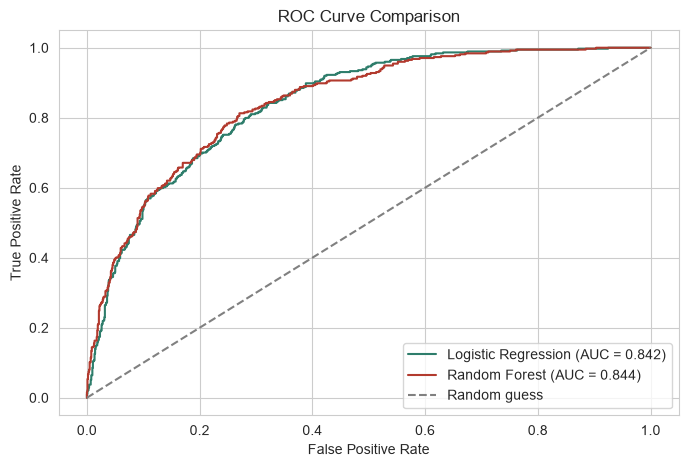

In [22]:
# ROC curves for both models -- shows the tradeoff between catching
# true churners vs. false alarms, across all possible decision thresholds
log_auc = roc_auc_score(y_test, log_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {log_auc:.3f})', color='#2E7D6B')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.3f})', color='#B23A2E')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


## 9. Feature Importance

Which factors actually drive churn the most, according to the Random
Forest model? This is often the most valuable business insight from
the whole project.

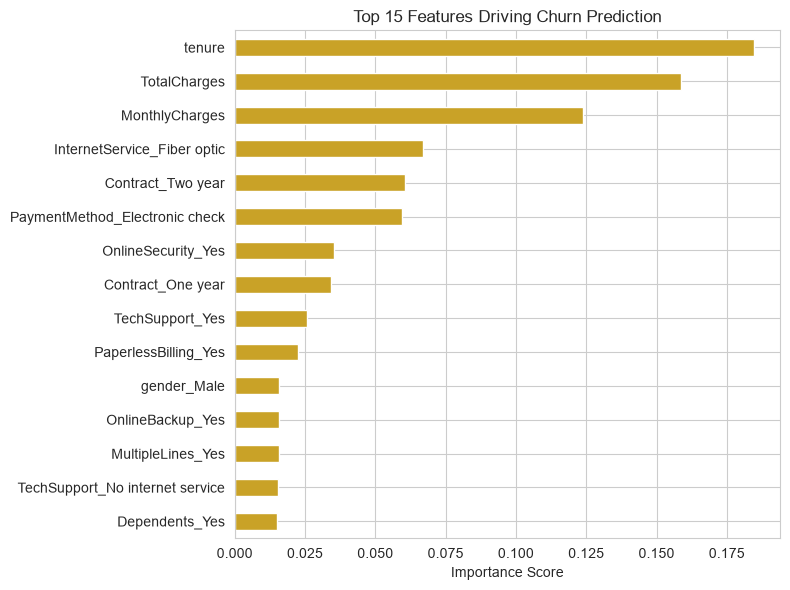

tenure                             0.184666
TotalCharges                       0.158575
MonthlyCharges                     0.123954
InternetService_Fiber optic        0.066907
Contract_Two year                  0.060375
PaymentMethod_Electronic check     0.059619
OnlineSecurity_Yes                 0.035278
Contract_One year                  0.034364
TechSupport_Yes                    0.025770
PaperlessBilling_Yes               0.022349
gender_Male                        0.015922
OnlineBackup_Yes                   0.015834
MultipleLines_Yes                  0.015727
TechSupport_No internet service    0.015288
Dependents_Yes                     0.015131
dtype: float64


In [23]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh', color='#C9A227')
plt.title('Top 15 Features Driving Churn Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(top_features)


In [ ]:
## 10. Conclusion & Business Insights

**Dataset overview:** 7,043 telecom customers, 20 features, no missing values
after cleaning. The dataset is moderately imbalanced -- 73.5% of customers
stayed, 26.5% churned.

**Model performance:** Logistic Regression achieved 80.7% accuracy (AUC 0.842),
and Random Forest achieved 80.6% accuracy (AUC 0.844). The two models are
essentially tied -- Random Forest edges ahead very slightly on AUC, while
Logistic Regression is marginally higher on raw accuracy. Given how close
they are, Logistic Regression is arguably the better choice in practice: it
performs just as well while being far easier to interpret and explain to a
non-technical stakeholder.

**Top churn drivers** (from Random Forest feature importance):
1. **Tenure** (18.5%) -- by far the strongest signal. Newer customers are
   much more likely to churn than long-tenured ones.
2. **Total Charges** (15.9%) and **Monthly Charges** (12.4%) -- pricing and
   cumulative spend are strong predictors, together outweighing tenure.
3. **Fiber optic internet service** (6.7%) -- customers on fiber optic plans
   churn at a notably higher rate than DSL or no-internet customers.
4. **Two-year contracts** (6.0%) -- unsurprisingly, longer contract
   commitments are associated with lower churn.

**Business recommendation:** Since tenure and contract length are the
strongest protective factors against churn, the clearest lever available is
converting new, month-to-month customers onto longer contracts early in
their lifecycle -- for example, via a retention offer or discount targeted
specifically at customers within their first few months. The elevated churn
rate among fiber optic customers is also worth investigating separately,
since it may point to a service quality or pricing issue specific to that
product line rather than a customer-profile issue.

**Model limitations:** Precision and recall for the churn class (1) are
noticeably weaker than for the non-churn class in both models (recall of
0.57 and 0.53 respectively) -- meaning both models miss a meaningful share
of customers who actually do churn. This is a common effect of class
imbalance (only 26.5% of customers churned) and would be worth addressing
with techniques like class weighting or resampling in a production version
of this model.